<a href="https://colab.research.google.com/github/kavyabuilds007-lab/MACHINE-LEARNING-PROJECTS/blob/main/HDD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("No GPU detected")

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install -q transformers scikit-learn pandas tqdm

In [ ]:
import os

PROJECT_DIR = "/content/drive/MyDrive/hallucination_detection"

os.makedirs(PROJECT_DIR, exist_ok=True)

print(PROJECT_DIR)

/content/drive/MyDrive/hallucination_detection


In [ ]:
!pip install -q transformers torch scikit-learn pandas tqdm

In [ ]:
import pandas as pd

DATA_PATH = "/content/drive/MyDrive/hallucination_detection/LLM_hallucination_dataset.csv"

df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
print(df.head())

Shape: (131988, 2)
                                                text  label
0  Question: How does the population of Honshu, t...      1
1  Question: Could you provide information on who...      0
2  Question: Can wearing masks help in preventing...      0
3  Question: Which television network has been in...      0
4  Question: Could you provide more information a...      1


In [ ]:
print(df.columns)
print(df["label"].value_counts())

Index(['text', 'label'], dtype='object')
label
0    73373
1    58615
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    df,
    test_size=0.20,
    stratify=df["label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 105590
Validation: 13199
Test: 13199


In [ ]:
from transformers import BertTokenizer, BertModel

MODEL_NAME = "bert-base-uncased"

tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)

bert = BertModel.from_pretrained(MODEL_NAME)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

bert = bert.to(device)
bert.eval()

print("Using:", device)

Using: cuda


In [ ]:
for param in bert.parameters():
    param.requires_grad = False

In [ ]:
trainable_params = sum(
    p.numel()
    for p in bert.parameters()
    if p.requires_grad
)

total_params = sum(
    p.numel()
    for p in bert.parameters()
)

print("Total BERT parameters:", total_params)
print("Trainable BERT parameters:", trainable_params)

Total BERT parameters: 109482240
Trainable BERT parameters: 0


In [ ]:
from torch.utils.data import Dataset

class HallucinationDataset(Dataset):

    def __init__(self, dataframe, tokenizer, max_length=256):

        self.texts = dataframe["text"].tolist()
        self.labels = dataframe["label"].astype(int).tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):

        encoding = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt"
        )

        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "label": torch.tensor(
                self.labels[idx],
                dtype=torch.long
            )
        }

In [ ]:
from torch.utils.data import DataLoader

train_dataset = HallucinationDataset(
    train_df,
    tokenizer
)

val_dataset = HallucinationDataset(
    val_df,
    tokenizer
)

test_dataset = HallucinationDataset(
    test_df,
    tokenizer
)

In [ ]:
BATCH_SIZE = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [ ]:
from tqdm.auto import tqdm

def extract_embeddings(loader):

    all_embeddings = []
    all_labels = []

    bert.eval()

    with torch.no_grad():

        for batch in tqdm(loader):

            input_ids = batch["input_ids"].to(
                device,
                non_blocking=True
            )

            attention_mask = batch["attention_mask"].to(
                device,
                non_blocking=True
            )

            outputs = bert(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            cls_embeddings = outputs.last_hidden_state[:, 0, :]

            all_embeddings.append(
                cls_embeddings.cpu()
            )

            all_labels.append(
                batch["label"]
            )

    embeddings = torch.cat(all_embeddings)
    labels = torch.cat(all_labels)

    return embeddings, labels

In [ ]:
train_embeddings, train_labels = extract_embeddings(
    train_loader
)

  0%|          | 0/1650 [00:00<?, ?it/s]

In [ ]:
 val_embeddings, val_labels = extract_embeddings(
    val_loader
)

  0%|          | 0/207 [00:00<?, ?it/s]

In [ ]:
test_embeddings, test_labels = extract_embeddings(
    test_loader)

  0%|          | 0/207 [00:00<?, ?it/s]

In [ ]:
train_df.to_csv(
    "/content/drive/MyDrive/hallucination_detection/train.csv",
    index=False
)

val_df.to_csv(
    "/content/drive/MyDrive/hallucination_detection/validation.csv",
    index=False
)

test_df.to_csv(
    "/content/drive/MyDrive/hallucination_detection/test.csv",
    index=False
)

In [ ]:
SAVE_DIR = "/content/drive/MyDrive/hallucination_detection"

torch.save(
    {
        "embeddings": train_embeddings,
        "labels": train_labels
    },
    f"{SAVE_DIR}/train_bert_embeddings.pt"
)

torch.save(
    {
        "embeddings": val_embeddings,
        "labels": val_labels
    },
    f"{SAVE_DIR}/val_bert_embeddings.pt"
)

torch.save(
    {
        "embeddings": test_embeddings,
        "labels": test_labels
    },
    f"{SAVE_DIR}/test_bert_embeddings.pt"
)

In [ ]:
import os

SAVE_DIR = "/content/drive/MyDrive/hallucination_detection"

print(os.listdir(SAVE_DIR))

['LLM_hallucination_dataset.csv', 'train.csv', 'validation.csv', 'test.csv', 'train_bert_embeddings.pt', 'val_bert_embeddings.pt', 'test_bert_embeddings.pt']


In [ ]:
import torch
from torch.utils.data import TensorDataset, DataLoader

SAVE_DIR = "/content/drive/MyDrive/hallucination_detection"

train_data = torch.load(
    f"{SAVE_DIR}/train_bert_embeddings.pt"
)

val_data = torch.load(
    f"{SAVE_DIR}/val_bert_embeddings.pt"
)

test_data = torch.load(
    f"{SAVE_DIR}/test_bert_embeddings.pt"
)

train_embeddings = train_data["embeddings"]
train_labels = train_data["labels"]

val_embeddings = val_data["embeddings"]
val_labels = val_data["labels"]

test_embeddings = test_data["embeddings"]
test_labels = test_data["labels"]

print("Train:", train_embeddings.shape)
print("Validation:", val_embeddings.shape)
print("Test:", test_embeddings.shape)

Train: torch.Size([105590, 768])
Validation: torch.Size([13199, 768])
Test: torch.Size([13199, 768])


In [ ]:
#Create DataLoaders - Because BERT is no longer involved, we can use a much larger batch size
EMBEDDING_BATCH_SIZE = 256

train_embedding_dataset = TensorDataset(
    train_embeddings,
    train_labels
)

val_embedding_dataset = TensorDataset(
    val_embeddings,
    val_labels
)

test_embedding_dataset = TensorDataset(
    test_embeddings,
    test_labels
)

train_embedding_loader = DataLoader(
    train_embedding_dataset,
    batch_size=EMBEDDING_BATCH_SIZE,
    shuffle=True
)

val_embedding_loader = DataLoader(
    val_embedding_dataset,
    batch_size=EMBEDDING_BATCH_SIZE,
    shuffle=False
)

test_embedding_loader = DataLoader(
    test_embedding_dataset,
    batch_size=EMBEDDING_BATCH_SIZE,
    shuffle=False
)

print("DataLoaders created.")

DataLoaders created.


In [ ]:
#Create the lightweight classifier - the model that will actually be trained
import torch.nn as nn

classifier = nn.Sequential(
    nn.Linear(768, 256),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(256, 2)
).to(device)

print(classifier)

Sequential(
  (0): Linear(in_features=768, out_features=256, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.3, inplace=False)
  (3): Linear(in_features=256, out_features=2, bias=True)
)


In [ ]:
#set loss and optimizer
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    classifier.parameters(),
    lr=2e-4,
    weight_decay=1e-4
)

In [ ]:
#adding validation
#We should not just train and look at training loss.
#We'll calculate validation loss and accuracy after every epoch.
from sklearn.metrics import accuracy_score

def evaluate_classifier(model, loader):

    model.eval()

    all_predictions = []
    all_labels = []

    total_loss = 0

    with torch.no_grad():

        for embeddings, labels in loader:

            embeddings = embeddings.to(device)
            labels = labels.to(device)

            logits = model(embeddings)

            loss = criterion(logits, labels)

            total_loss += loss.item()

            predictions = torch.argmax(
                logits,
                dim=1
            )

            all_predictions.extend(
                predictions.cpu().numpy()
            )

            all_labels.extend(
                labels.cpu().numpy()
            )

    average_loss = total_loss / len(loader)

    accuracy = accuracy_score(
        all_labels,
        all_predictions
    )

    return average_loss, accuracy

In [ ]:
history = {
    "epoch": [],
    "train_loss": [],
    "val_loss": [],
    "val_accuracy": []
}

In [ ]:
#Training loop with automatic checkpoint saving - saving after each epoch
from tqdm.auto import tqdm

EPOCHS = 3

for epoch in range(EPOCHS):

    classifier.train()

    total_loss = 0

    progress_bar = tqdm(
        train_embedding_loader,
        desc=f"Epoch {epoch + 1}/{EPOCHS}"
    )

    for embeddings, labels in progress_bar:

        embeddings = embeddings.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        logits = classifier(embeddings)

        loss = criterion(
            logits,
            labels
        )

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

        progress_bar.set_postfix(
            loss=f"{loss.item():.4f}"
        )

    train_loss = total_loss / len(
        train_embedding_loader
    )

    # Validation
    val_loss, val_accuracy = evaluate_classifier(
        classifier,
        val_embedding_loader
    )
    print(f"\nEpoch {epoch + 1}/{EPOCHS}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Validation Loss: {val_loss:.4f}")
    print(f"Validation Accuracy: {val_accuracy:.4f}")
    history["epoch"].append(epoch + 1)
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_accuracy)

    # SAVE CHECKPOINT AFTER EACH EPOCH
    checkpoint = {
        "epoch": epoch + 1,
        "model_state_dict": classifier.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "train_loss": train_loss,
        "val_loss": val_loss,
        "val_accuracy": val_accuracy
    }

    checkpoint_path = (
        f"{SAVE_DIR}/"
        f"classifier_checkpoint_epoch_{epoch + 1}.pt"
    )

    torch.save(
        checkpoint,
        checkpoint_path
    )

    print(
        f"Checkpoint saved: {checkpoint_path}"
    )

Epoch 1/3:   0%|          | 0/413 [00:00<?, ?it/s]


Epoch 1/3
Train Loss: 0.6262
Validation Loss: 0.6309
Validation Accuracy: 0.6344
Checkpoint saved: /content/drive/MyDrive/hallucination_detection/classifier_checkpoint_epoch_1.pt


Epoch 2/3:   0%|          | 0/413 [00:00<?, ?it/s]


Epoch 2/3
Train Loss: 0.6212
Validation Loss: 0.6299
Validation Accuracy: 0.6360
Checkpoint saved: /content/drive/MyDrive/hallucination_detection/classifier_checkpoint_epoch_2.pt


Epoch 3/3:   0%|          | 0/413 [00:00<?, ?it/s]


Epoch 3/3
Train Loss: 0.6163
Validation Loss: 0.6258
Validation Accuracy: 0.6433
Checkpoint saved: /content/drive/MyDrive/hallucination_detection/classifier_checkpoint_epoch_3.pt


In [ ]:
FINAL_MODEL_PATH = (
    f"{SAVE_DIR}/"
    "bert_hallucination_classifier_final.pt"
)

torch.save(
    classifier.state_dict(),
    FINAL_MODEL_PATH
)

print(
    "Final classifier saved to:"
)
print(FINAL_MODEL_PATH)

Final classifier saved to:
/content/drive/MyDrive/hallucination_detection/bert_hallucination_classifier_final.pt


In [ ]:
print(train_embeddings.shape)
print(val_embeddings.shape)
print(test_embeddings.shape)

torch.Size([105590, 768])
torch.Size([13199, 768])
torch.Size([13199, 768])


In [ ]:
#classifier training checkpoint
FINAL_MODEL_PATH = (
    "/content/drive/MyDrive/hallucination_detection/"
    "bert_hallucination_classifier_final.pt"
)

torch.save(
    classifier.state_dict(),
    FINAL_MODEL_PATH
)

print("Classifier saved.")

Classifier saved.


In [38]:
#Recreate and load your trained classifier
#Because you already saved: bert_hallucination_classifier_final.pt
#we load that model instead of training again.
import torch.nn as nn

classifier = nn.Sequential(
    nn.Linear(768, 256),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(256, 2)
).to(device)

FINAL_MODEL_PATH = (
    f"{SAVE_DIR}/bert_hallucination_classifier_final.pt"
)

classifier.load_state_dict(
    torch.load(
        FINAL_MODEL_PATH,
        map_location=device
    )
)

classifier.eval()

print("Final classifier loaded successfully.")

Final classifier loaded successfully.


In [40]:
batch = next(iter(test_loader))

print(type(batch))

if isinstance(batch, (list, tuple)):
    print("Number of items in batch:", len(batch))
    for i, item in enumerate(batch):
        print(i, type(item), getattr(item, "shape", None))

<class 'dict'>


In [41]:
batch = next(iter(test_loader))

print(batch.keys())

for key, value in batch.items():
    print(key, type(value), getattr(value, "shape", None))

dict_keys(['input_ids', 'attention_mask', 'label'])
input_ids <class 'torch.Tensor'> torch.Size([64, 256])
attention_mask <class 'torch.Tensor'> torch.Size([64, 256])
label <class 'torch.Tensor'> torch.Size([64])


In [42]:
from torch.utils.data import TensorDataset, DataLoader

test_embedding_dataset = TensorDataset(
    test_embeddings,
    test_labels
)

test_embedding_loader = DataLoader(
    test_embedding_dataset,
    batch_size=256,
    shuffle=False
)

print("Test embedding loader created.")
print("Number of test batches:", len(test_embedding_loader))

Test embedding loader created.
Number of test batches: 52


In [43]:
#test one batch
batch = next(iter(test_embedding_loader))

print("Number of items:", len(batch))
print("Embeddings shape:", batch[0].shape)
print("Labels shape:", batch[1].shape)

Number of items: 2
Embeddings shape: torch.Size([256, 768])
Labels shape: torch.Size([256])


In [44]:
#evaluate trained classifier
from tqdm.auto import tqdm
import numpy as np

all_predictions = []
all_probabilities = []
all_labels = []

classifier.eval()

with torch.no_grad():

    for embeddings, labels in tqdm(
        test_embedding_loader,
        desc="Evaluating test set"
    ):

        embeddings = embeddings.to(device)

        logits = classifier(embeddings)

        probabilities = torch.softmax(
            logits,
            dim=1
        )

        predictions = torch.argmax(
            probabilities,
            dim=1
        )

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_probabilities.extend(
            probabilities.cpu().numpy()
        )

        all_labels.extend(
            labels.numpy()
        )

y_true = np.array(all_labels)
y_pred = np.array(all_predictions)
y_prob = np.array(all_probabilities)

print("Evaluation completed.")
print("Number of test samples:", len(y_true))

Evaluating test set:   0%|          | 0/52 [00:00<?, ?it/s]

Evaluation completed.
Number of test samples: 13199


In [45]:
#intermediate evaluation - Calculate Accuracy, Precision, Recall, F1, and ROC-AUC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(
    y_true,
    y_pred,
    pos_label=1
)
recall = recall_score(
    y_true,
    y_pred,
    pos_label=1
)
f1 = f1_score(
    y_true,
    y_pred,
    pos_label=1
)
roc_auc = roc_auc_score(
    y_true,
    y_prob[:, 1]
)
print("BERT Hallucination Detector — Test Set")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

BERT Hallucination Detector — Test Set
Accuracy : 0.6433
Precision: 0.6238
Recall   : 0.4955
F1-Score : 0.5523
ROC-AUC  : 0.6889


In [46]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=[
            "FACTUAL",
            "NON-FACTUAL / HALLUCINATED"
        ],
        digits=4
    )
)

                            precision    recall  f1-score   support

                   FACTUAL     0.6539    0.7614    0.7036      7338
NON-FACTUAL / HALLUCINATED     0.6238    0.4955    0.5523      5861

                  accuracy                         0.6433     13199
                 macro avg     0.6389    0.6284    0.6279     13199
              weighted avg     0.6406    0.6433    0.6364     13199



Confusion Matrix:
[[5587 1751]
 [2957 2904]]


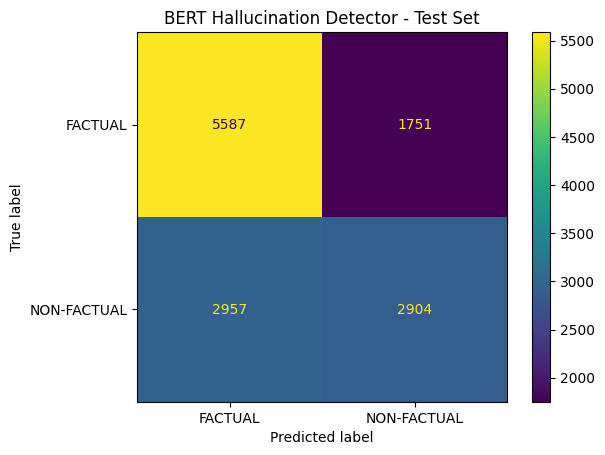

In [47]:
#confusion matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(
    y_true,
    y_pred
)
print("Confusion Matrix:")
print(cm)
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "FACTUAL",
        "NON-FACTUAL"
    ]
)
disp.plot()
plt.title("BERT Hallucination Detector - Test Set")
plt.show()

In [48]:
#save mnetrics
import pandas as pd

evaluation_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ],
    "Score": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ]
})

evaluation_results.to_csv(
    f"{SAVE_DIR}/bert_test_metrics.csv",
    index=False
)

cm_df = pd.DataFrame(
    cm,
    index=["Actual FACTUAL", "Actual NON-FACTUAL"],
    columns=["Predicted FACTUAL", "Predicted NON-FACTUAL"]
)

cm_df.to_csv(
    f"{SAVE_DIR}/bert_test_confusion_matrix.csv"
)

print("Test metrics and confusion matrix saved to Google Drive.")

Test metrics and confusion matrix saved to Google Drive.


In [49]:
#save predictions
test_results = pd.DataFrame({
    "true_label": y_true,
    "predicted_label": y_pred,
    "prob_factual": y_prob[:, 0],
    "prob_hallucinated": y_prob[:, 1]
})

test_results.to_csv(
    f"{SAVE_DIR}/bert_test_predictions.csv",
    index=False
)

print("Test predictions saved.")

Test predictions saved.
